<a href="https://colab.research.google.com/github/sagara-pathum/Skit-learn/blob/main/6_pre_processing_tools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# i use a download csv file. so that i need to upload it. i use google.colab files function
from google.colab import files

In [ ]:
files.upload()

Saving drawndata1.csv to drawndata1.csv


{'drawndata1.csv': b'x,y,z\n58.08036546458079,225.69904242013214,a\n238.86735657018107,247.45664533360318,a\n156.2182119517779,286.5887823312221,a\n262.00436148462643,284.25144485233085,a\n185.2431825058747,308.18757148244987,a\n180.09569912269114,289.5690882028012,a\n254.56718191478356,288.4341276209697,a\n283.5874877257717,305.6088287884648,a\n133.74999977995202,311.21552649265095,a\n429.6608111315931,265.006662249905,a\n332.9108956656902,261.581219078956,a\n336.778928114184,256.30749793850794,a\n16.112922878620367,191.08319105496932,a\n231.96795342420876,208.907045997853,a\n275.9376364766166,220.1571364694461,a\n401.96768776121223,182.0340899372203,a\n33.47851678603797,175.72226928798943,a\n142.18762234626757,188.44536548057013,a\n237.55891927960457,177.0920712527336,a\n155.17277634634502,178.87797011965833,a\n40.16810779330431,217.43813129082318,a\n122.38225362455758,221.4633669299093,a\n40.695092324574034,236.8489270263377,a\n18.61207027470455,233.5007106638863,a\n-0.0303318944764

In [ ]:
import pandas as pd
import numpy as np
import sklearn

In [ ]:
# load csv file to the project as a dataframe
df = pd.read_csv("drawndata1.csv")

In [ ]:
# lets see a little
df.head(3)

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a


In [ ]:
# refere this to see how the data subsets are selected. //https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html
# simply first bracket is 'selection' , sedond bracket is 'data frame'
# values here do is conver dataframe to series. so that plot can work. because plot dont work with data frames
X = df[["x","y"]]

type(X)

y = df["z"] == "a"


pandas.core.frame.DataFrame

In [ ]:
X = X.values
type(X)

numpy.ndarray

In [ ]:
# type(df[["z"]]=="a")
# print(df[["z"]]=="a")
# check these for more understanding

In [ ]:
import matplotlib.pyplot as plt

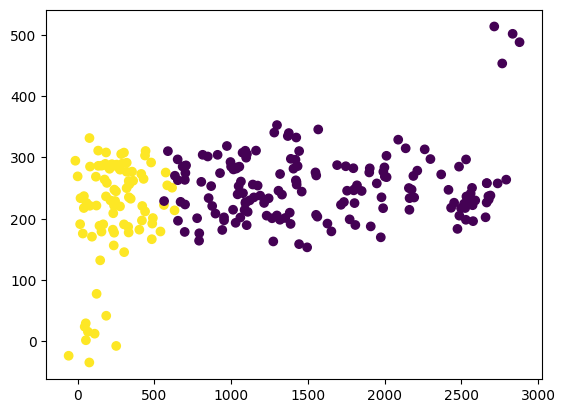

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y)

## api kalin assign karagaththa y ta values wagayak ewa kare class label che karala. ethkoata class eka 'a' wena ewa true widiyatath nathi ewa false widiyatath enawa. dan e agayanuth me plot ke color wata dala thiyenne
## ehtakota eke point warga dekata wena wenama illakam dekak pennawa . 0 .1

#  **** **** 0
#  **** **** 0
#  **** **** 1

# ethakota me function eka e wenas ilakkam wala widiyata wena wenama paata karanwa



In [ ]:
# note these things here. there are two outlier groups. and x and y axis are in very defferent scale. effect depends on the model we are using. how ever in general models are sensitive to these things.

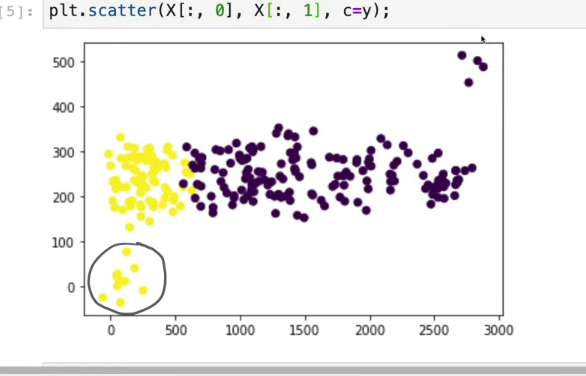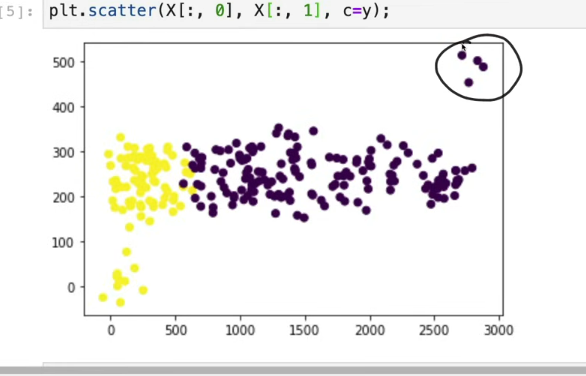

In [58]:
# so we need to scale , but keeping the information not damaged.
# we can do it using 'standard scaler' . what it do is taking the z values for each of the features

from sklearn.preprocessing import StandardScaler

# lets make standardscaler object
sc = StandardScaler()

# now we can use the '.fit_transform' function to scaling the dataframe

In [59]:
sc.fit_transform(X) ## note that this works with both .vales (nd array) and (data frame)

array([[-1.28490284e+00, -2.02938609e-01],
       [-1.07019011e+00,  1.06286357e-01],
       [-1.16834885e+00,  6.62442922e-01],
       [-1.04271130e+00,  6.29224047e-01],
       [-1.13387717e+00,  9.69410783e-01],
       [-1.13999061e+00,  7.04799839e-01],
       [-1.05154411e+00,  6.88669471e-01],
       [-1.01707798e+00,  9.32760991e-01],
       [-1.19503336e+00,  1.01244490e+00],
       [-8.43593131e-01,  3.55711966e-01],
       [-9.58498740e-01,  3.07028637e-01],
       [-9.53904849e-01,  2.32077079e-01],
       [-1.33474572e+00, -6.94908496e-01],
       [-1.07838422e+00, -4.41591025e-01],
       [-1.02616337e+00, -2.81701682e-01],
       [-8.76483033e-01, -8.23516780e-01],
       [-1.31412137e+00, -9.13222090e-01],
       [-1.18501236e+00, -7.32397990e-01],
       [-1.07174408e+00, -8.93754092e-01],
       [-1.16959047e+00, -8.68372412e-01],
       [-1.30617644e+00, -3.20344923e-01],
       [-1.20853433e+00, -2.63137180e-01],
       [-1.30555057e+00, -4.44734188e-02],
       [-1.

In [60]:
X1 = sc.fit_transform(X) ## note that this works with both .vales (nd array) and (data frame)

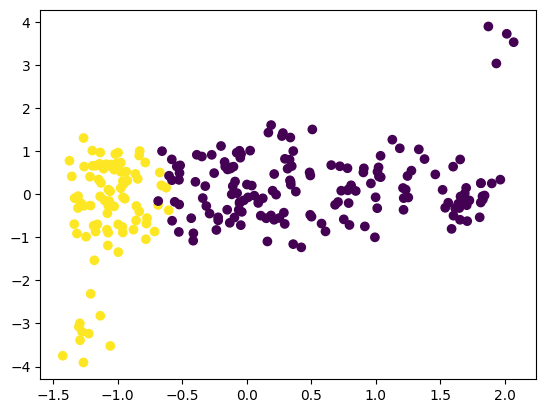

In [61]:
plt.scatter(X1[:,0],X1[:,1],c=y)

In [62]:
# now we can see that this is acceptable
# but still y axis is like 8 unit, and x axis is like 3.5 units
# and we still have outliers

# so lets see what scaler we have to avoid these options

# fortunately we have a solution for this. it is 'Quantile transformer'. please refere the video 40:12--43:23 https://www.youtube.com/watch?v=0B5eIE_1vpU

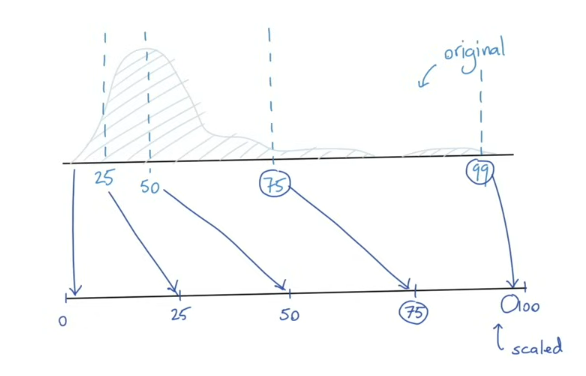

In [63]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer()

X2_= qt.fit_transform(X)

# here you can see sklearn gives us a warning that default number of qnatiles is larger than the number of sample in the data set. so that we have to change that using an attribute of the quantile transformer object
# attribute name is 'n_quantile'

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


In [66]:
qt1 = QuantileTransformer(n_quantiles=100)

X2 = qt1.fit_transform(X)

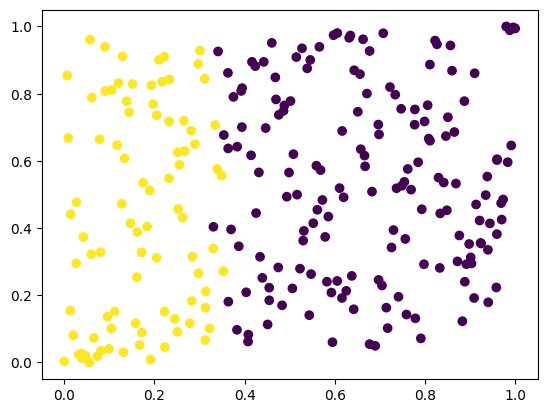

In [67]:
# now lets see the plot

plt.scatter(X2[:,0],X2[:,1],c=y)

In [ ]:
# seems nice.
# same scale
# outliers can be considerable